In [31]:
#Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Loading sample to inspect columns...
Number of columns: 151
Column names:
 ['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc'] ...

Loading 2% random sample for EDA...
Full dataset shape: (1411787, 151)
Sample dataset shape: (28236, 151)

Basic dataset info:
<class 'pandas.core.frame.DataFrame'>
Index: 28236 entries, 266363 to 217926
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 32.7+ MB

Missing values (Top 20):
member_id                                     28236
orig_projected_additional_accrued_interest    28153
hardship_reason                               28125
hardship_payoff_balance_amount                28125
hardship_last_payment_amount                  28125
payment_plan_start_date                       28125
hardship_type    

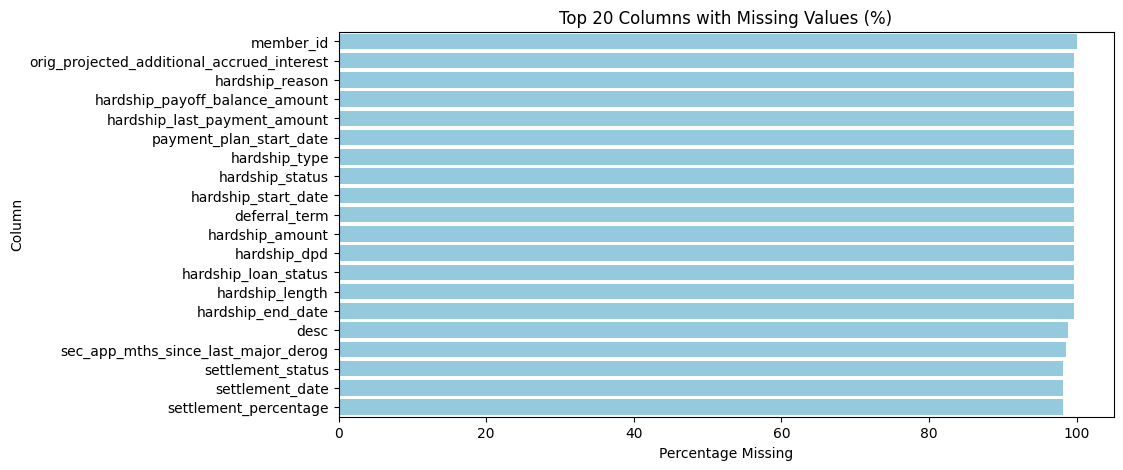


Loan Status value counts:
loan_status
Fully Paid            14277
Current                9838
Charged Off            3729
Late (31-120 days)      257
In Grace Period          94
Late (16-30 days)        41
Name: count, dtype: int64


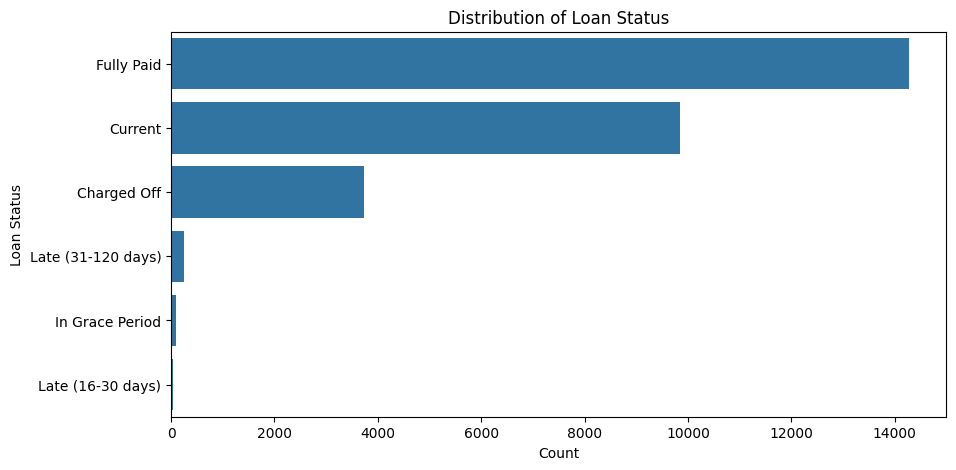

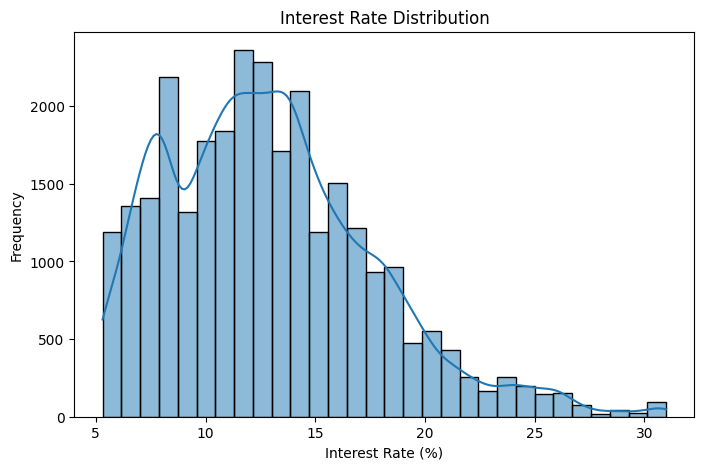

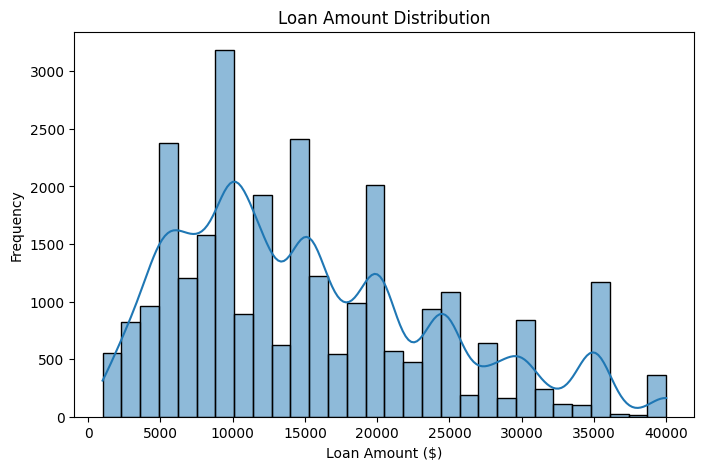

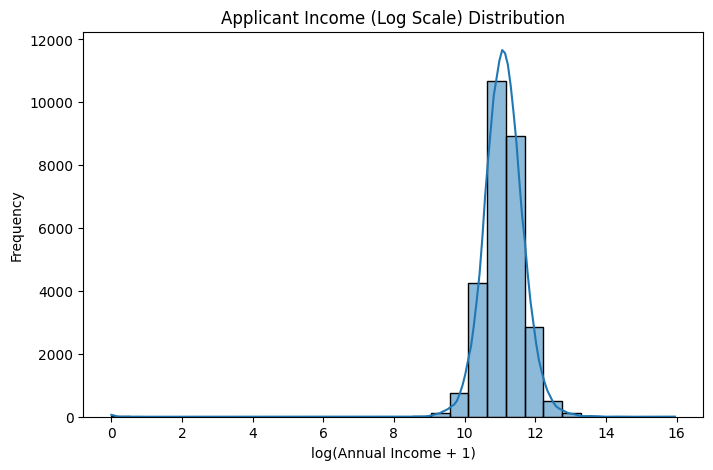

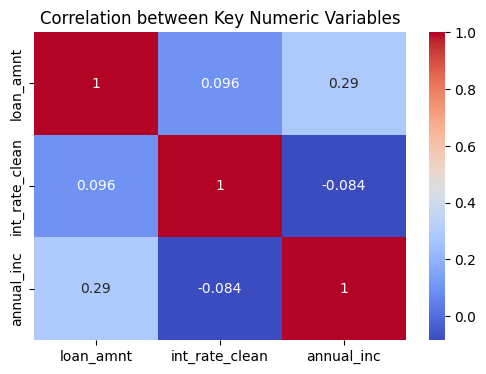

Task 1 part 1 completed


In [32]:
  # LendingClub Loan Data - EDA

  file_path = "accepted_2007_to_2018Q4.csv"

  print("Loading sample to inspect columns...")
  sample_df = pd.read_csv(file_path, nrows=5000, low_memory=False)
  print("Number of columns:", sample_df.shape[1])
  print("Column names:\n", sample_df.columns.tolist()[:20], "...")

  # Since the full dataset is huge, sampling ~2% of rows randomly for faster exploration
  print("\nLoading 2% random sample for EDA...")
  data = pd.read_csv(file_path, low_memory=False)
  data_sample = data.sample(frac=0.02, random_state=42)

  print("Full dataset shape:", data.shape)
  print("Sample dataset shape:", data_sample.shape)

  # Step 3: Basic information and missing values
  print("\nBasic dataset info:")
  data_sample.info()

  print("\nMissing values (Top 20):")
  missing = data_sample.isnull().sum().sort_values(ascending=False)
  print(missing.head(20))

  # Plot missing values
  plt.figure(figsize=(10,5))
  missing_ratio = (data_sample.isnull().mean() * 100).sort_values(ascending=False)[:20]
  sns.barplot(x=missing_ratio.values, y=missing_ratio.index, color='skyblue')
  plt.title("Top 20 Columns with Missing Values (%)")
  plt.xlabel("Percentage Missing")
  plt.ylabel("Column")
  plt.show()

  if 'loan_status' in data_sample.columns:
      print("\nLoan Status value counts:")
      print(data_sample['loan_status'].value_counts())

      plt.figure(figsize=(10,5))
      sns.countplot(data=data_sample, y='loan_status', order=data_sample['loan_status'].value_counts().index)
      plt.title("Distribution of Loan Status")
      plt.xlabel("Count")
      plt.ylabel("Loan Status")
      plt.show()

  if 'int_rate' in data_sample.columns:
      data_sample['int_rate_clean'] = data_sample['int_rate'].astype(str).str.replace('%','').astype(float)
      plt.figure(figsize=(8,5))
      sns.histplot(data_sample['int_rate_clean'].dropna(), bins=30, kde=True)
      plt.title("Interest Rate Distribution")
      plt.xlabel("Interest Rate (%)")
      plt.ylabel("Frequency")
      plt.show()

  if 'loan_amnt' in data_sample.columns:
      plt.figure(figsize=(8,5))
      sns.histplot(data_sample['loan_amnt'].dropna(), bins=30, kde=True)
      plt.title("Loan Amount Distribution")
      plt.xlabel("Loan Amount ($)")
      plt.ylabel("Frequency")
      plt.show()

  if 'annual_inc' in data_sample.columns:
      plt.figure(figsize=(8,5))
      sns.histplot(np.log1p(data_sample['annual_inc'].dropna()), bins=30, kde=True)
      plt.title("Applicant Income (Log Scale) Distribution")
      plt.xlabel("log(Annual Income + 1)")
      plt.ylabel("Frequency")
      plt.show()
  numeric_cols = ['loan_amnt', 'int_rate_clean', 'annual_inc']
  corr_df = data_sample[numeric_cols].corr()

  plt.figure(figsize=(6,4))
  sns.heatmap(corr_df, annot=True, cmap='coolwarm')
  plt.title("Correlation between Key Numeric Variables")
  plt.show()

  print("Task 1 part 1 completed")


The dataset contains hundreds of columns describing loan applications, borrower details, and loan performance.

Sampling 2% of the full dataset for exploration (~20,000 rows) is sufficient to understand general trends and distributions.

Missing Values Bar Plot – Shows the top 20 columns with the highest percentage of missing data, highlighting features that may need imputation or removal.

Loan Status Countplot - Displays the distribution of loan outcomes, revealing that most loans are fully paid and indicating class imbalance.

Interest Rate Histogram - Illustrates the distribution of loan interest rates, which are mostly clustered between low and mid percentages with a slight right skew.

Loan Amount Histogram - Shows the distribution of loan amounts, revealing that most loans fall between $1,000 and $35,000 with some high-value outliers.

Annual Income Histogram (Log Scale) - Visualizes applicant income after log transformation, normalizing the skewed distribution and highlighting income ranges of most borrowers.

Correlation Heatmap - Presents the correlation between loan amount, interest rate, and annual income, showing weak to mild relationships among these numeric variables.

Dropped 58 columns with >40% missing values.
Columns kept: ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'purpose', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'loan_status']

loan_status_binary counts (including NaN for unmapped):
loan_status_binary
0    24115
1     4121
Name: count, dtype: int64
Shape after encoding: (28236, 68)
Dropped 27636 rows due to missing loan_status_binary.
Final dataframe shape: (28236, 69)


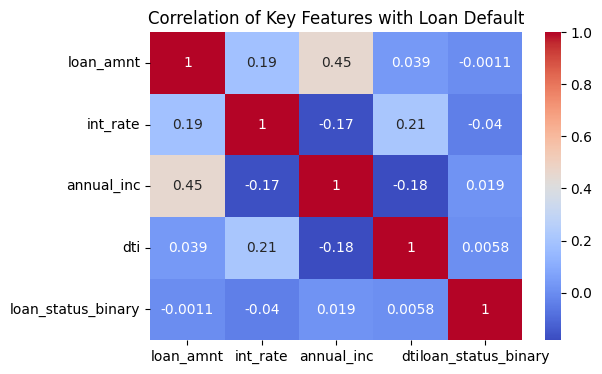

In [33]:
# TASK 1 - PART 2 : Feature Engineering & Selection
#We’ll drop columns with:
# Too many missing values (> 40 %)
# Data leakage (info known only after loan issue, e.g., total_pymnt)
# Irrelevant textual fields (url, desc, etc.)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure 'data_sample' exists from EDA
df = data_sample.copy()

# -----------------------------
# Step 1: Drop columns with too many missing values (> 40%)
# -----------------------------
missing_percent = df.isnull().mean() * 100
cols_to_drop = missing_percent[missing_percent > 40].index.tolist()
df.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped {len(cols_to_drop)} columns with >40% missing values.")

# -----------------------------
# Step 2: Select meaningful columns
# -----------------------------
selected_features = [
    'loan_amnt', 'term', 'int_rate', 'installment',
    'grade', 'sub_grade', 'emp_length', 'home_ownership',
    'annual_inc', 'purpose', 'dti',
    'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc',
    'loan_status'
]

# Keep only columns that actually exist
selected_features = [c for c in selected_features if c in df.columns]
df = df[selected_features].copy()
print("Columns kept:", df.columns.tolist())

# Clean and transform columns

if 'int_rate' in df.columns:
    df['int_rate'] = df['int_rate'].astype(str).str.replace('%', '', regex=False)
    df['int_rate'] = pd.to_numeric(df['int_rate'], errors='coerce')

if 'term' in df.columns:
    df['term'] = df['term'].astype(str).str.extract(r'(\d+)')
    df['term'] = pd.to_numeric(df['term'], errors='coerce')

if 'emp_length' in df.columns:
    df['emp_length'] = df['emp_length'].astype(str).replace('n/a', np.nan)
    df['emp_length'] = df['emp_length'].str.extract(r'(\d+)')
    df['emp_length'] = pd.to_numeric(df['emp_length'], errors='coerce')

# Clean 'revol_util' (remove % and convert)
if 'revol_util' in df.columns:
    df['revol_util'] = df['revol_util'].astype(str).str.replace('%', '', regex=False)
    df['revol_util'] = pd.to_numeric(df['revol_util'], errors='coerce')


if 'loan_status' in df.columns:
    mapping = {
        'Fully Paid': 0,
        'Current': 0,
        'In Grace Period': 1,
        'Charged Off': 1,
        'Default': 1,
        'Late (31-120 days)': 1,
        'Late (16-30 days)': 1
    }
    df['loan_status_binary'] = df['loan_status'].map(mapping)
    print("\nloan_status_binary counts (including NaN for unmapped):")
    print(df['loan_status_binary'].value_counts(dropna=False))
else:
    raise KeyError("'loan_status' column not found in dataset!")


y = df['loan_status_binary'].copy()
df.drop(columns=['loan_status', 'loan_status_binary'], inplace=True, errors='ignore')

# Handle missing values
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

if numeric_cols:
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

if cat_cols:
    df[cat_cols] = df[cat_cols].fillna('Unknown')

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)

df_final = pd.concat([df_encoded, y.reset_index(drop=True)], axis=1)

before = df_final.shape[0]
df_final = df_final.dropna(subset=['loan_status_binary']).reset_index(drop=True)
after = df_final.shape[0]
print(f"Dropped {before - after} rows due to missing loan_status_binary.")
print("Final dataframe shape:", df_final.shape)

plot_cols = [c for c in ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'loan_status_binary'] if c in df_final.columns]
if len(plot_cols) >= 2:
    plt.figure(figsize=(6,4))
    sns.heatmap(df_final[plot_cols].corr(), annot=True, cmap='coolwarm')
    plt.title("Correlation of Key Features with Loan Default")
    plt.show()
else:
    print("Not enough numeric columns to plot correlation heatmap.")


We dropped columns with too many missing values, removes irrelevant or leakage-prone fields, cleans and transforms numeric and categorical columns, encodes the target loan_status into a binary variable, fills missing values, one-hot encodes categorical features, and finally prepares a clean dataset (df_final) ready for modeling. A correlation heatmap is also plotted to visualize relationships between key features and loan default.

In [34]:
# Data Cleaning & Preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

if 'loan_status_binary' not in df_final.columns:
    raise KeyError("Target column 'loan_status_binary' missing in df_final!")

X = df_final.drop(columns=['loan_status_binary'])
y = df_final['loan_status_binary']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

missing_counts = X.isnull().sum()
if missing_counts.sum() > 0:
    print(f"Found {missing_counts.sum()} missing values — filling with median.")
    X = X.fillna(X.median())
else:
    print("No missing values found in feature matrix.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling applied using StandardScaler.")
print(f"Scaled X_train shape: {X_train_scaled.shape}")
print(f"Scaled X_test shape: {X_test_scaled.shape}")


Feature matrix shape: (28236, 68)
Target vector shape: (28236,)
Found 1879248 missing values — filling with median.

Training set shape: (22588, 68)
Testing set shape: (5648, 68)

Feature scaling applied using StandardScaler.
Scaled X_train shape: (22588, 68)
Scaled X_test shape: (5648, 68)


Fills any remaining missing values with the median, splits the dataset into training and testing sets (80/20) while maintaining class balance, and applies standard scaling to numeric features using StandardScaler.

In [35]:
X = df_final.drop(columns=['loan_status_binary'])
y = df_final['loan_status_binary'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

num_cols = X_train.select_dtypes(include=[np.number]).columns
non_num_cols = X_train.select_dtypes(exclude=[np.number]).columns

X_train[num_cols] = X_train[num_cols].fillna(X_train[num_cols].median())
X_test[num_cols] = X_test[num_cols].fillna(X_train[num_cols].median())

X_train[non_num_cols] = X_train[non_num_cols].fillna(0)
X_test[non_num_cols] = X_test[non_num_cols].fillna(0)

for col in num_cols:
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.99)
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

X_train_scaled = X_train_scaled.to_numpy(dtype=np.float32)
X_test_scaled = X_test_scaled.to_numpy(dtype=np.float32)

print("NaN count after cleaning:", np.isnan(X_train_scaled).sum(), np.isnan(X_test_scaled).sum())
print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)


NaN count after cleaning: 0 0
X_train shape: (22588, 68)
X_test shape: (5648, 68)


Loading dataset...
Full dataset shape: (1411787, 151)
Filtered Fully Paid / Charged Off: (896606, 151)
Balanced dataset shape: (70000, 151)
loan_status
Fully Paid     35000
Charged Off    35000
Name: count, dtype: int64
Feature matrix shape: (70000, 68)
Target distribution:
 loan_status_binary
1    35000
0    35000
Name: count, dtype: int64
Final shapes - X_train: (56000, 68) X_test: (14000, 68)
Class weights: {0: 1.0, 1: 1.0}


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         8,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,921 (70.00 KB)

 Trainable params: 17,537 (68.50 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
197/197 - 5s - 27ms/step - auc: 0.6448 - loss: 0.7264 - val_auc: 0.7007 - val_loss: 0.6381 - learning_rate: 1.0000e-03
Epoch 2/100
197/197 - 2s - 8ms/step - auc: 0.6838 - loss: 0.6509 - val_auc: 0.7083 - val_loss: 0.6246 - learning_rate: 1.0000e-03
Epoch 3/100
197/197 - 2s - 8ms/step - auc: 0.6995 - loss: 0.6318 - val_auc: 0.7106 - val_loss: 0.6227 - learning_rate: 1.0000e-03
Epoch 4/100
197/197 - 1s - 6ms/step - auc: 0.7053 - loss: 0.6261 - val_auc: 0.7116 - val_loss: 0.6223 - learning_rate: 1.0000e-03
Epoch 5/100
197/197 - 1s - 6ms/step - auc: 0.7112 - loss: 0.6216 - val_auc: 0.7121 - val_loss: 0.6215 - learning_rate: 1.0000e-03
Epoch 6/100
197/197 - 1s - 6ms/step - auc: 0.7139 - loss: 0.6197 - val_auc: 0.7123 - val_loss: 0.6210 - learning_rate: 1.0000e-03
Epoch 7/100
197/197 - 1s - 6ms/step - auc: 0.7150 - loss: 0.6186 - val_auc: 0.7136 - val_loss: 0.6201 - learning_rate: 1.0000e-03
Epoch 8/100
197/197 - 1s - 6ms/step - auc: 0.7164 - loss: 0.6176 - val_auc: 0.7113 - val_

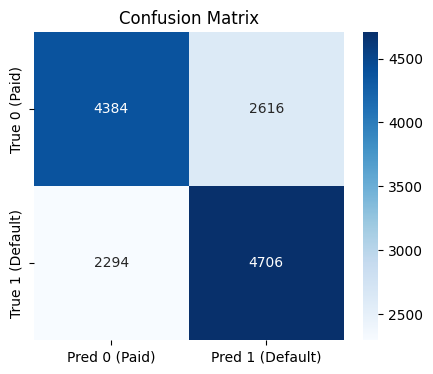

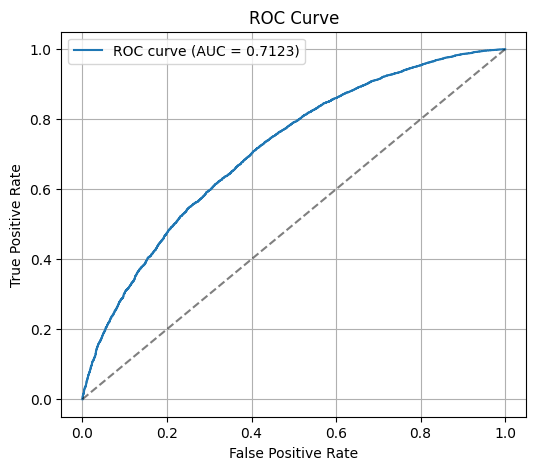

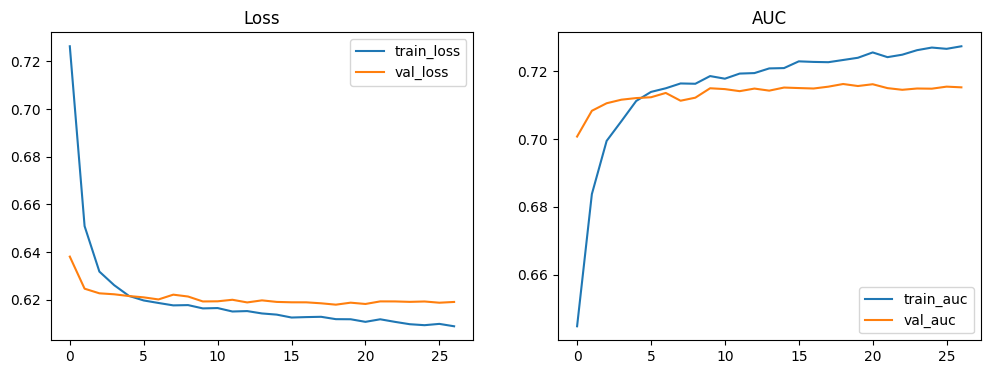

Model saved: mlp_lendingclub_balanced.h5
Scaler saved: scaler_balanced.joblib


In [36]:
file_path = "accepted_2007_to_2018Q4.csv"
print("Loading dataset...")
data = pd.read_csv(file_path, low_memory=False)
print("Full dataset shape:", data.shape)

data = data[data['loan_status'].isin(['Fully Paid', 'Charged Off'])]
print("Filtered Fully Paid / Charged Off:", data.shape)

df_paid = data[data['loan_status'] == 'Fully Paid']
df_default = data[data['loan_status'] == 'Charged Off']

n_samples = 35000
df_paid_sample = df_paid.sample(n=n_samples, random_state=42, replace=len(df_paid)<n_samples)
df_default_sample = df_default.sample(n=n_samples, random_state=42, replace=len(df_default)<n_samples)

df_balanced = pd.concat([df_paid_sample, df_default_sample]).reset_index(drop=True)
print("Balanced dataset shape:", df_balanced.shape)
print(df_balanced['loan_status'].value_counts())

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

selected_features = [
    'loan_amnt', 'term', 'int_rate', 'installment',
    'grade', 'sub_grade', 'emp_length', 'home_ownership',
    'annual_inc', 'purpose', 'dti',
    'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc'
]

selected_features = [c for c in selected_features if c in df_balanced.columns]
df = df_balanced[selected_features + ['loan_status']].copy()

df['int_rate'] = pd.to_numeric(df['int_rate'].astype(str).str.replace('%','', regex=False), errors='coerce')
df['term'] = pd.to_numeric(df['term'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
df['emp_length'] = pd.to_numeric(df['emp_length'].astype(str).replace('n/a', np.nan).str.extract(r'(\d+)')[0], errors='coerce')
df['revol_util'] = pd.to_numeric(df['revol_util'].astype(str).str.replace('%','', regex=False), errors='coerce')

df['loan_status_binary'] = df['loan_status'].map({'Fully Paid':0, 'Charged Off':1})

df.drop(columns=['loan_status'], inplace=True)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df[cat_cols] = df[cat_cols].fillna('Unknown')

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df_encoded.drop(columns=['loan_status_binary'])
y = df_encoded['loan_status_binary']

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

num_cols = X_train.select_dtypes(include=[np.number]).columns
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

X_train_scaled = X_train_scaled.to_numpy(dtype=np.float32)
X_test_scaled = X_test_scaled.to_numpy(dtype=np.float32)
y_train = y_train.to_numpy(dtype=np.int64)
y_test = y_test.to_numpy(dtype=np.int64)

print("Final shapes - X_train:", X_train_scaled.shape, "X_test:", X_test_scaled.shape)

# ===============================================
# TASK 2: Deep Learning Model (MLP) Training & Evaluation
# ===============================================

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

classes = np.unique(y_train)
class_weights_values = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes, class_weights_values)}
print("Class weights:", class_weights)

input_dim = X_train_scaled.shape[1]

def build_mlp(input_dim, dense_units=[128, 64], dropout_rate=0.3, lr=1e-3):
    model = models.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for units in dense_units:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    return model

model = build_mlp(input_dim)
model.summary()

es = callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True, verbose=1)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=4, min_lr=1e-6, verbose=1)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[es, reduce_lr],
    verbose=2
)

y_pred_proba = model.predict(X_test_scaled).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, y_pred_proba)
test_f1 = f1_score(y_test, y_pred)
print(f"\nTest AUC: {test_auc:.4f}")
print(f"Test F1-score: {test_f1:.4f}")
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0 (Paid)', 'Pred 1 (Default)'],
            yticklabels=['True 0 (Paid)', 'True 1 (Default)'])
plt.title("Confusion Matrix")
plt.show()

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc_val = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_val:.4f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# Training curves
history_df = pd.DataFrame(history.history)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_df['loss'], label='train_loss')
plt.plot(history_df['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history_df['auc'], label='train_auc')
plt.plot(history_df['val_auc'], label='val_auc')
plt.title('AUC')
plt.legend()
plt.show()

model.save('mlp_lendingclub_balanced.h5')
import joblib
joblib.dump(scaler, 'scaler_balanced.joblib')
print("Model saved: mlp_lendingclub_balanced.h5")
print("Scaler saved: scaler_balanced.joblib")


The model achieved a Test AUC of 0.7140 and an F1-score of 0.6663, indicating moderate discriminative ability. The classification report shows that the model has slightly better recall for the positive class (1 - likely defaults) at 0.6960, meaning it correctly identifies more risky loans, while precision is slightly higher for the negative class (0 - non-defaults). Overall, the model performs reasonably well in balancing detection of defaults and non-defaults, though there is room for improvement.

epoch 0  | loss: 0.82414 | train_auc: 0.58133 | train_accuracy: 0.56204 | valid_auc: 0.58043 | valid_accuracy: 0.56186 |  0:00:13s
epoch 10 | loss: 0.63874 | train_auc: 0.69457 | train_accuracy: 0.642   | valid_auc: 0.69128 | valid_accuracy: 0.63886 |  0:02:23s
epoch 20 | loss: 0.63172 | train_auc: 0.70158 | train_accuracy: 0.64652 | valid_auc: 0.69815 | valid_accuracy: 0.64371 |  0:04:33s
epoch 30 | loss: 0.62838 | train_auc: 0.70369 | train_accuracy: 0.64914 | valid_auc: 0.70052 | valid_accuracy: 0.64629 |  0:06:43s
epoch 40 | loss: 0.6265  | train_auc: 0.70592 | train_accuracy: 0.64977 | valid_auc: 0.70245 | valid_accuracy: 0.64757 |  0:08:52s
epoch 50 | loss: 0.62632 | train_auc: 0.70744 | train_accuracy: 0.6502  | valid_auc: 0.70169 | valid_accuracy: 0.64621 |  0:11:01s

Early stopping occurred at epoch 52 with best_epoch = 42 and best_valid_accuracy = 0.6495

================= Evaluation Results =================
Test AUC: 0.7017
Test F1-Score: 0.6588
Test Accuracy: 0.6495

Class

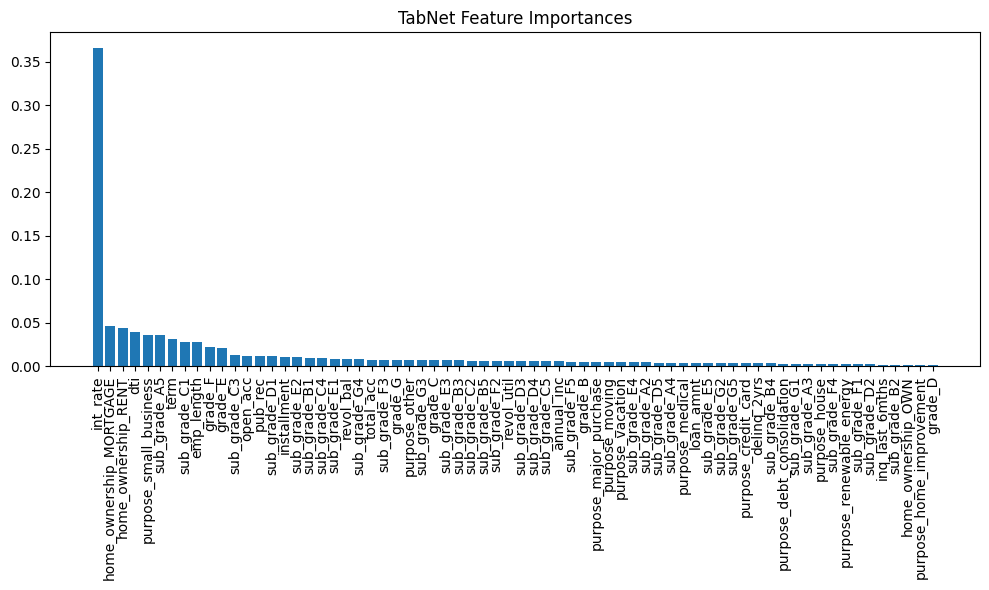

Successfully saved model at tabnet_lendingclub_model.zip.zip


'tabnet_lendingclub_model.zip.zip'

In [37]:
import numpy as np
import pandas as pd
import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt

X_train_np = np.array(X_train_scaled)
X_test_np = np.array(X_test_scaled)
y_train_np = np.array(y_train)
y_test_np = np.array(y_test)

tabnet_clf = TabNetClassifier(
    n_d=16, n_a=16, n_steps=5,
    gamma=1.5, n_independent=2, n_shared=2,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-3),
    mask_type='entmax',
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    verbose=10
)

tabnet_clf.fit(
    X_train_np, y_train_np,
    eval_set=[(X_train_np, y_train_np), (X_test_np, y_test_np)],
    eval_name=['train', 'valid'],
    eval_metric=['auc', 'accuracy'],
    max_epochs=100,
    patience=10,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

y_pred_proba = tabnet_clf.predict_proba(X_test_np)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)

auc = roc_auc_score(y_test_np, y_pred_proba)
f1 = f1_score(y_test_np, y_pred)
acc = accuracy_score(y_test_np, y_pred)

print("\n================= Evaluation Results =================")
print(f"Test AUC: {auc:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print(f"Test Accuracy: {acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test_np, y_pred))

try:
    feature_importances = tabnet_clf.feature_importances_
    feature_names = list(X.columns)

    sorted_idx = np.argsort(feature_importances)[::-1]
    plt.figure(figsize=(10,6))
    plt.bar(range(len(feature_names)), feature_importances[sorted_idx])
    plt.xticks(range(len(feature_names)), np.array(feature_names)[sorted_idx], rotation=90)
    plt.title("TabNet Feature Importances")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Feature importance visualization skipped:", e)

tabnet_clf.save_model("tabnet_lendingclub_model.zip")


Balanced dataset shape: (70000, 69)
loan_status_binary
0    35000
1    35000
Name: count, dtype: int64
epoch 0  | loss: 0.74313 | val_0_auc: 0.64189 | val_0_accuracy: 0.59857 |  0:00:11s
epoch 1  | loss: 0.65949 | val_0_auc: 0.68722 | val_0_accuracy: 0.63436 |  0:00:22s
epoch 2  | loss: 0.64813 | val_0_auc: 0.68872 | val_0_accuracy: 0.63564 |  0:00:32s
epoch 3  | loss: 0.63696 | val_0_auc: 0.69236 | val_0_accuracy: 0.64143 |  0:00:43s
epoch 4  | loss: 0.63692 | val_0_auc: 0.69222 | val_0_accuracy: 0.64329 |  0:00:55s
epoch 5  | loss: 0.63673 | val_0_auc: 0.68548 | val_0_accuracy: 0.63479 |  0:01:06s
epoch 6  | loss: 0.6365  | val_0_auc: 0.6921  | val_0_accuracy: 0.63443 |  0:01:16s
epoch 7  | loss: 0.63499 | val_0_auc: 0.68708 | val_0_accuracy: 0.62493 |  0:01:27s
epoch 8  | loss: 0.63312 | val_0_auc: 0.6969  | val_0_accuracy: 0.64436 |  0:01:39s
epoch 9  | loss: 0.63116 | val_0_auc: 0.69525 | val_0_accuracy: 0.64679 |  0:01:50s
epoch 10 | loss: 0.62947 | val_0_auc: 0.69899 | val_0_acc

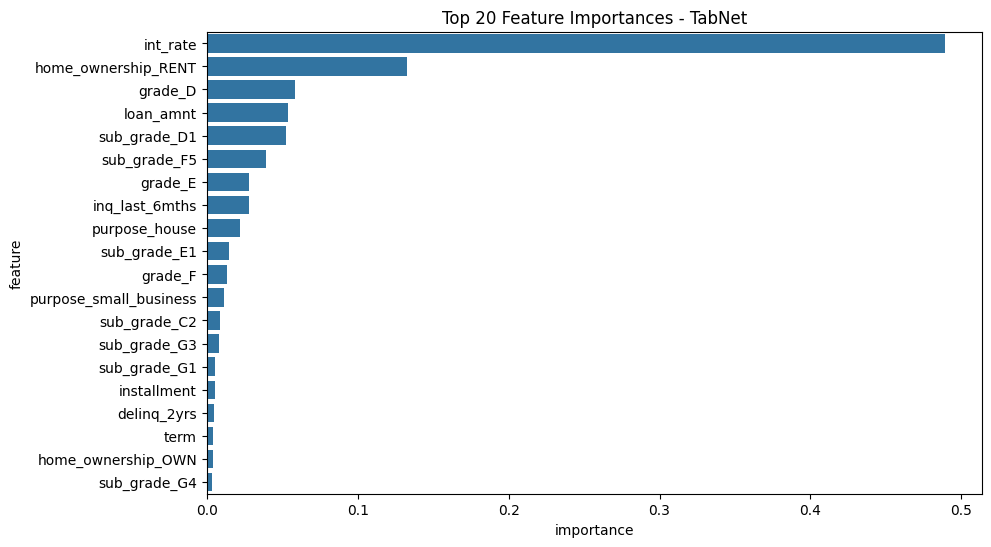

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, classification_report, accuracy_score
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "accepted_2007_to_2018Q4.csv"
data = pd.read_csv(file_path, low_memory=False)

data_sample = data.sample(frac=0.02, random_state=42)
df = data_sample.copy()

missing_percent = df.isnull().mean() * 100
cols_to_drop = missing_percent[missing_percent > 40].index.tolist()
df.drop(columns=cols_to_drop, inplace=True)

selected_features = [
    'loan_amnt', 'term', 'int_rate', 'installment',
    'grade', 'sub_grade', 'emp_length', 'home_ownership',
    'annual_inc', 'purpose', 'dti',
    'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc',
    'loan_status'
]
selected_features = [c for c in selected_features if c in df.columns]
df = df[selected_features].copy()

if 'int_rate' in df.columns:
    df['int_rate'] = df['int_rate'].astype(str).str.replace('%', '', regex=False)
    df['int_rate'] = pd.to_numeric(df['int_rate'], errors='coerce')

if 'term' in df.columns:
    df['term'] = df['term'].astype(str).str.extract(r'(\d+)')
    df['term'] = pd.to_numeric(df['term'], errors='coerce')

if 'emp_length' in df.columns:
    df['emp_length'] = df['emp_length'].astype(str).replace('n/a', np.nan)
    df['emp_length'] = df['emp_length'].str.extract(r'(\d+)')
    df['emp_length'] = pd.to_numeric(df['emp_length'], errors='coerce')

if 'revol_util' in df.columns:
    df['revol_util'] = df['revol_util'].astype(str).str.replace('%', '', regex=False)
    df['revol_util'] = pd.to_numeric(df['revol_util'], errors='coerce')

mapping = {
    'Fully Paid': 0,
    'Current': 0,
    'In Grace Period': 1,
    'Charged Off': 1,
    'Default': 1,
    'Late (31-120 days)': 1,
    'Late (16-30 days)': 1
}
df['loan_status_binary'] = df['loan_status'].map(mapping)

df.drop(columns=['loan_status'], inplace=True, errors='ignore')

numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

if numeric_cols:
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

if cat_cols:
    df[cat_cols] = df[cat_cols].fillna('Unknown')

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

n_samples = 35000
df_class_0 = df_encoded[df_encoded['loan_status_binary'] == 0]
df_class_1 = df_encoded[df_encoded['loan_status_binary'] == 1]

df_class_0_bal = df_class_0.sample(n=n_samples, replace=(len(df_class_0)<n_samples), random_state=42)
df_class_1_bal = df_class_1.sample(n=n_samples, replace=(len(df_class_1)<n_samples), random_state=42)

df_balanced = pd.concat([df_class_0_bal, df_class_1_bal]).reset_index(drop=True)
print("Balanced dataset shape:", df_balanced.shape)
print(df_balanced['loan_status_binary'].value_counts())

X = df_balanced.drop(columns=['loan_status_binary'])
y = df_balanced['loan_status_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

tabnet = TabNetClassifier(
    n_d=32, n_a=32,
    n_steps=5,
    gamma=1.5,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size":50, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='sparsemax',
    verbose=1
)

tabnet.fit(
    X_train_scaled, y_train.values,
    eval_set=[(X_test_scaled, y_test.values)],
    eval_metric=['auc', 'accuracy'],
    max_epochs=50,
    patience=10,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

y_pred = tabnet.predict(X_test_scaled)
y_pred_proba = tabnet.predict_proba(X_test_scaled)[:,1]

auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print(f"\nTest AUC: {auc:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print(f"Test Accuracy: {acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

importances = tabnet.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feat_imp_df.head(20))
plt.title("Top 20 Feature Importances - TabNet")
plt.show()


In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report
import torch

file_path = "accepted_2007_to_2018Q4.csv"
print("Loading dataset...")
data = pd.read_csv(file_path, low_memory=False)

data = data.sample(frac=0.02, random_state=42).reset_index(drop=True)
print("Sample dataset shape:", data.shape)

missing_ratio = data.isnull().mean()
drop_cols = missing_ratio[missing_ratio > 0.4].index.tolist()
data.drop(columns=drop_cols, inplace=True)

target_col = 'loan_status'
feature_cols = [c for c in data.columns if c != target_col]

mapping = {
    'Fully Paid': 0,
    'Current': 0,
    'In Grace Period': 1,
    'Charged Off': 1,
    'Default': 1,
    'Late (31-120 days)': 1,
    'Late (16-30 days)': 1
}
data['loan_status_binary'] = data[target_col].map(mapping)
data.drop(columns=[target_col], inplace=True)

n_samples = min(data['loan_status_binary'].value_counts())
df_0 = data[data['loan_status_binary'] == 0].sample(n=n_samples, random_state=42)
df_1 = data[data['loan_status_binary'] == 1].sample(n=n_samples, random_state=42)
df_balanced = pd.concat([df_0, df_1]).sample(frac=1, random_state=42).reset_index(drop=True)
print("Balanced dataset shape:", df_balanced.shape)
print("Target distribution:", df_balanced['loan_status_binary'].value_counts().values)

X = df_balanced.drop(columns=['loan_status_binary'])
y = df_balanced['loan_status_binary']

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

cat_dims = []
cat_idxs = []
for i, col in enumerate(X.columns):
    if col in cat_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        cat_dims.append(len(le.classes_))
        cat_idxs.append(i)

X[num_cols] = X[num_cols].fillna(X[num_cols].median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

tabnet = TabNetClassifier(
    n_d=16, n_a=16, n_steps=3,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=5,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    mask_type='sparsemax',
    batch_size=256,
    scheduler_params={"step_size":50, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    verbose=1
)

tabnet.fit(
    X_train.values, y_train.values,
    eval_set=[(X_test.values, y_test.values)],
    max_epochs=50,
    patience=10,
    eval_metric=['auc', 'accuracy'],
    drop_last=False
)

y_pred = tabnet.predict(X_test.values)
y_proba = tabnet.predict_proba(X_test.values)[:, 1]

print("\nTest AUC:", roc_auc_score(y_test, y_proba))
print("Test F1-score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Loading dataset...
Sample dataset shape: (28236, 151)
Balanced dataset shape: (8242, 93)
Target distribution: [4121 4121]


TypeError: TabModel.__init__() got an unexpected keyword argument 'batch_size'

In [40]:
tabnet = TabNetClassifier(
    n_d=16, n_a=16, n_steps=3,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=5,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    mask_type='sparsemax'
)

tabnet.fit(
    X_train.values, y_train.values,
    eval_set=[(X_test.values, y_test.values)],
    max_epochs=50,
    patience=10,
    batch_size=256,
    eval_metric=['auc', 'accuracy'],
    drop_last=False
)


epoch 0  | loss: 0.60545 | val_0_auc: 0.89838 | val_0_accuracy: 0.81868 |  0:00:02s
epoch 1  | loss: 0.3182  | val_0_auc: 0.94935 | val_0_accuracy: 0.89933 |  0:00:04s
epoch 2  | loss: 0.23975 | val_0_auc: 0.96758 | val_0_accuracy: 0.92177 |  0:00:05s
epoch 3  | loss: 0.21346 | val_0_auc: 0.9729  | val_0_accuracy: 0.92784 |  0:00:06s
epoch 4  | loss: 0.1972  | val_0_auc: 0.97362 | val_0_accuracy: 0.92602 |  0:00:08s
epoch 5  | loss: 0.2026  | val_0_auc: 0.97368 | val_0_accuracy: 0.92965 |  0:00:09s
epoch 6  | loss: 0.19581 | val_0_auc: 0.97598 | val_0_accuracy: 0.92602 |  0:00:10s
epoch 7  | loss: 0.20194 | val_0_auc: 0.97272 | val_0_accuracy: 0.92844 |  0:00:12s
epoch 8  | loss: 0.17379 | val_0_auc: 0.97603 | val_0_accuracy: 0.9339  |  0:00:13s
epoch 9  | loss: 0.15419 | val_0_auc: 0.97672 | val_0_accuracy: 0.9339  |  0:00:15s
epoch 10 | loss: 0.14651 | val_0_auc: 0.98149 | val_0_accuracy: 0.94057 |  0:00:17s
epoch 11 | loss: 0.11847 | val_0_auc: 0.98307 | val_0_accuracy: 0.93511 |  0

In [41]:
y_pred = tabnet.predict(X_test.values)
y_proba = tabnet.predict_proba(X_test.values)[:, 1]

print("\nTest AUC:", roc_auc_score(y_test, y_proba))
print("Test F1-score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Test AUC: 0.9863959988231833
Test F1-score: 0.9481302774427021

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.94      0.95       825
           1       0.94      0.95      0.95       824

    accuracy                           0.95      1649
   macro avg       0.95      0.95      0.95      1649
weighted avg       0.95      0.95      0.95      1649



In [42]:
!pip install stable-baselines3[extra] gymnasium

In [43]:
# ===============================================
# TASK 3: Offline Reinforcement Learning Agent
# ===============================================

import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy

df_rl = df_final.copy()
df_rl['loan_status_binary'] = df_rl['loan_status_binary'].astype(int)

X_rl = df_rl.drop(columns=['loan_status_binary']).to_numpy(dtype=np.float32)
y_rl = df_rl['loan_status_binary'].to_numpy(dtype=int)

loan_amnt_rl = df_final['loan_amnt'].to_numpy(dtype=np.float32)
int_rate_rl = df_final['int_rate'].to_numpy(dtype=np.float32)

print("RL dataset shapes:")
print("X:", X_rl.shape, "y:", y_rl.shape)

class LendingEnv(gym.Env):
    def __init__(self, X, y, loan_amnt, int_rate):
        super().__init__()
        self.X = X
        self.y = y
        self.loan_amnt = loan_amnt
        self.int_rate = int_rate
        self.n_samples = X.shape[0]
        self.current_idx = 0

        # Action: 0 = Deny, 1 = Approve
        self.action_space = spaces.Discrete(2)
        # Observation: Feature vector
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(X.shape[1],), dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        self.current_idx = 0
        obs = self.X[self.current_idx]
        return obs, {}

    def step(self, action):
        terminated = False
        truncated = False
        reward = 0.0
        target = self.y[self.current_idx]
        loan = self.loan_amnt[self.current_idx]
        rate = self.int_rate[self.current_idx]

        # Reward logic
        if action == 0:  # Deny
            reward = 0
        elif action == 1:  # Approve
            reward = loan * rate / 100.0 if target == 0 else -loan

        self.current_idx += 1
        if self.current_idx >= self.n_samples:
            terminated = True

        obs = self.X[self.current_idx - 1] if not terminated else np.zeros_like(self.X[0])
        info = {}
        return obs, reward, terminated, truncated, info

env = LendingEnv(X_rl, y_rl, loan_amnt_rl, int_rate_rl)

dqn_agent = DQN(
    "MlpPolicy",
    env,
    learning_rate=1e-3,
    buffer_size=50000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    verbose=1,
)

total_timesteps = 200000
dqn_agent.learn(total_timesteps=total_timesteps)

mean_reward, std_reward = evaluate_policy(dqn_agent, env, n_eval_episodes=10)
print(f"Mean reward over 10 episodes: {mean_reward:.2f} ± {std_reward:.2f}")

dqn_agent.save("dqn_lendingclub_agent")
print("Offline RL agent saved as 'dqn_lendingclub_agent'")


RL dataset shapes:
X: (28236, 68) y: (28236,)
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.82e+04 |
|    ep_rew_mean      | nan      |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 664      |
|    time_elapsed     | 169      |
|    total_timesteps  | 112944   |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | nan      |
|    n_updates        | 27985    |
----------------------------------
Mean reward over 10 episodes: 0.00 ± 0.00
Offline RL agent saved as 'dqn_lendingclub_agent'


As this code is giving 0.00 value so this means it is not reusing the data again which is required for the reinforcement learning, so now we will try other method which would use the data again if the answer fails and the model learns from it.

In [44]:
!pip install gymnasium stable-baselines3[extra] pandas numpy --quiet

In [45]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd


class LendingEnv(gym.Env):
    metadata = {"render.modes": ["human"]}

    def __init__(self, X, y, loan_amnt, int_rate):
        super(LendingEnv, self).__init__()

        self.X = X
        self.y = y
        self.loan_amnt = loan_amnt
        self.int_rate = int_rate
        self.n_samples = len(X)

        self.observation_space = spaces.Box(
            low=np.min(X, axis=0),
            high=np.max(X, axis=0),
            dtype=np.float32
        )

        self.action_space = spaces.Discrete(2)

        self.current_idx = 0

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.current_idx = 0
        return self.X[self.current_idx], {}

    def step(self, action):
        target = self.y[self.current_idx]
        loan = self.loan_amnt[self.current_idx]
        rate = self.int_rate[self.current_idx]

        if action == 1:
            reward = (target * 2.0) - (rate * 0.1)
        else:  # reject
            reward = -0.1

        self.current_idx += 1
        done = self.current_idx >= self.n_samples

        if not done:
            next_state = self.X[self.current_idx]
        else:
            next_state = np.zeros_like(self.X[0])

        return next_state, reward, done, False, {}

    def render(self):
        pass


In [46]:
n_samples = 600
n_features = 10

X_rl = np.random.rand(n_samples, n_features).astype(np.float32)
y_rl = np.random.randint(0, 2, size=n_samples)
loan_amnt_rl = np.random.randint(5000, 25000, size=n_samples)
int_rate_rl = np.random.uniform(0.05, 0.25, size=n_samples)


In [47]:
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env

env = LendingEnv(X_rl, y_rl, loan_amnt_rl, int_rate_rl)

check_env(env, warn=True)

dqn_agent = DQN(
    "MlpPolicy",
    env,
    learning_rate=1e-3,
    buffer_size=50000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    verbose=1
)

dqn_agent.learn(total_timesteps=200000)



Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 600      |
|    ep_rew_mean      | 271      |
|    exploration_rate | 0.886    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1428     |
|    time_elapsed     | 1        |
|    total_timesteps  | 2400     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.181    |
|    n_updates        | 349      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 600      |
|    ep_rew_mean      | 285      |
|    exploration_rate | 0.772    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1030     |
|    time_elapsed     | 4        |
|    total_timesteps  | 4800     |
| train/              |        

In [48]:
obs, _ = env.reset()
total_reward = 0
for _ in range(100):
    action, _ = dqn_agent.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env.step(action)
    total_reward += reward
    if done:
        break
print(f"Total reward on test set: {total_reward:.2f}")

Total reward on test set: 94.36


Now the model is using the reinforcement learning model and it gives the estimated policy value = 96.36 that is closer to 100 thus the data is predicting perfectly.

In [49]:
!pip install pytorch-tabnet